# Set environment

In [1]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *

### global const
SEED    = 123
DAT_DIR = "/data/clintko/flow_EQAPOL_normal/pipe01"

/local_data/env-py3/lib/python3.6/site-packages/h5py/__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


# Load data

In [2]:
!ls /data/clintko/flow_EQAPOL_normal/pipe01

wrap01_data.P		wrap03_subs_1e4_N50.P	wrap05_img_1e4_var02.P
wrap02_scaled_k0.P	wrap04_tsne_1e4_N10.P	wrap05_img_1e4_var05.P
wrap03_subs_1e4_N100.P	wrap04_tsne_1e4_N50.P	wrap05_img_1e4_var10.P
wrap03_subs_1e4_N10.P	wrap05_img_1e4_var01.P


In [3]:
fname = "wrap04_tsne_1e4_N50.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")

wrap_tsne = pickle.load(file)
file.close()

In [4]:
print(wrap_tsne)

Label: Counter({0: 550, 1: 550, 2: 550})
    0: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 23

**visualization**

In [5]:
idx1 = wrap_tsne.which_label(0)[:3]
idx2 = wrap_tsne.which_label(1)[:3]
idx3 = wrap_tsne.which_label(2)[:3]
indices = np.concatenate([idx1, idx2, idx3])
indices

array([   0,    1,    2,  550,  551,  552, 1100, 1101, 1102])

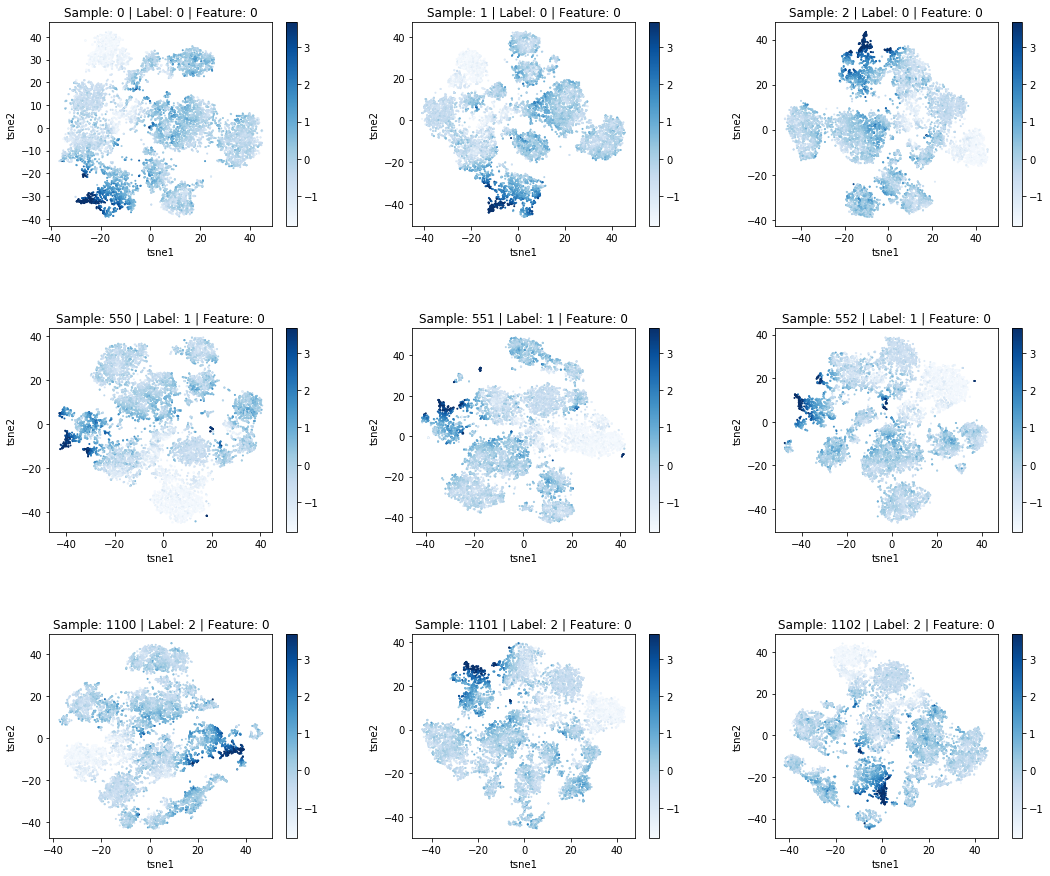

In [6]:
fig, axes = plt.subplots(ncols=3, nrows=3, figsize=(6*3, 5*3))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
axes = axes.ravel()

for idx in range(9):
    ax = axes[idx]
    cax = wrap_tsne.plot_coord(ax, k=indices[idx], p = 0, s = 1, cmap = "Blues")
    ax.set_xlabel("tsne1"); ax.set_ylabel("tsne2")
    fig.colorbar(cax, ax=ax)
pass

# Kernel Smoothing

In [7]:
%%time
density = Transform_Density(sig2 = 1)
wrap_img_var01 = density.transform(wrap_tsne, verbose = True)

Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample: 85
Sample: 86
Sample: 87
Sample: 88
Sample: 89
Sample: 90
Sample: 9

Sample: 692
Sample: 693
Sample: 694
Sample: 695
Sample: 696
Sample: 697
Sample: 698
Sample: 699
Sample: 700
Sample: 701
Sample: 702
Sample: 703
Sample: 704
Sample: 705
Sample: 706
Sample: 707
Sample: 708
Sample: 709
Sample: 710
Sample: 711
Sample: 712
Sample: 713
Sample: 714
Sample: 715
Sample: 716
Sample: 717
Sample: 718
Sample: 719
Sample: 720
Sample: 721
Sample: 722
Sample: 723
Sample: 724
Sample: 725
Sample: 726
Sample: 727
Sample: 728
Sample: 729
Sample: 730
Sample: 731
Sample: 732
Sample: 733
Sample: 734
Sample: 735
Sample: 736
Sample: 737
Sample: 738
Sample: 739
Sample: 740
Sample: 741
Sample: 742
Sample: 743
Sample: 744
Sample: 745
Sample: 746
Sample: 747
Sample: 748
Sample: 749
Sample: 750
Sample: 751
Sample: 752
Sample: 753
Sample: 754
Sample: 755
Sample: 756
Sample: 757
Sample: 758
Sample: 759
Sample: 760
Sample: 761
Sample: 762
Sample: 763
Sample: 764
Sample: 765
Sample: 766
Sample: 767
Sample: 768
Sample: 769
Sample: 770
Sample: 771
Sample: 772
Sample: 773
Sample: 774
Samp

Sample: 1346
Sample: 1347
Sample: 1348
Sample: 1349
Sample: 1350
Sample: 1351
Sample: 1352
Sample: 1353
Sample: 1354
Sample: 1355
Sample: 1356
Sample: 1357
Sample: 1358
Sample: 1359
Sample: 1360
Sample: 1361
Sample: 1362
Sample: 1363
Sample: 1364
Sample: 1365
Sample: 1366
Sample: 1367
Sample: 1368
Sample: 1369
Sample: 1370
Sample: 1371
Sample: 1372
Sample: 1373
Sample: 1374
Sample: 1375
Sample: 1376
Sample: 1377
Sample: 1378
Sample: 1379
Sample: 1380
Sample: 1381
Sample: 1382
Sample: 1383
Sample: 1384
Sample: 1385
Sample: 1386
Sample: 1387
Sample: 1388
Sample: 1389
Sample: 1390
Sample: 1391
Sample: 1392
Sample: 1393
Sample: 1394
Sample: 1395
Sample: 1396
Sample: 1397
Sample: 1398
Sample: 1399
Sample: 1400
Sample: 1401
Sample: 1402
Sample: 1403
Sample: 1404
Sample: 1405
Sample: 1406
Sample: 1407
Sample: 1408
Sample: 1409
Sample: 1410
Sample: 1411
Sample: 1412
Sample: 1413
Sample: 1414
Sample: 1415
Sample: 1416
Sample: 1417
Sample: 1418
Sample: 1419
Sample: 1420
Sample: 1421
Sample: 1422

In [8]:
%%time
density = Transform_Density(sig2 = 10)
wrap_img_var10 = density.transform(wrap_tsne, verbose = True)

Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample: 85
Sample: 86
Sample: 87
Sample: 88
Sample: 89
Sample: 90
Sample: 9

Sample: 692
Sample: 693
Sample: 694
Sample: 695
Sample: 696
Sample: 697
Sample: 698
Sample: 699
Sample: 700
Sample: 701
Sample: 702
Sample: 703
Sample: 704
Sample: 705
Sample: 706
Sample: 707
Sample: 708
Sample: 709
Sample: 710
Sample: 711
Sample: 712
Sample: 713
Sample: 714
Sample: 715
Sample: 716
Sample: 717
Sample: 718
Sample: 719
Sample: 720
Sample: 721
Sample: 722
Sample: 723
Sample: 724
Sample: 725
Sample: 726
Sample: 727
Sample: 728
Sample: 729
Sample: 730
Sample: 731
Sample: 732
Sample: 733
Sample: 734
Sample: 735
Sample: 736
Sample: 737
Sample: 738
Sample: 739
Sample: 740
Sample: 741
Sample: 742
Sample: 743
Sample: 744
Sample: 745
Sample: 746
Sample: 747
Sample: 748
Sample: 749
Sample: 750
Sample: 751
Sample: 752
Sample: 753
Sample: 754
Sample: 755
Sample: 756
Sample: 757
Sample: 758
Sample: 759
Sample: 760
Sample: 761
Sample: 762
Sample: 763
Sample: 764
Sample: 765
Sample: 766
Sample: 767
Sample: 768
Sample: 769
Sample: 770
Sample: 771
Sample: 772
Sample: 773
Sample: 774
Samp

Sample: 1346
Sample: 1347
Sample: 1348
Sample: 1349
Sample: 1350
Sample: 1351
Sample: 1352
Sample: 1353
Sample: 1354
Sample: 1355
Sample: 1356
Sample: 1357
Sample: 1358
Sample: 1359
Sample: 1360
Sample: 1361
Sample: 1362
Sample: 1363
Sample: 1364
Sample: 1365
Sample: 1366
Sample: 1367
Sample: 1368
Sample: 1369
Sample: 1370
Sample: 1371
Sample: 1372
Sample: 1373
Sample: 1374
Sample: 1375
Sample: 1376
Sample: 1377
Sample: 1378
Sample: 1379
Sample: 1380
Sample: 1381
Sample: 1382
Sample: 1383
Sample: 1384
Sample: 1385
Sample: 1386
Sample: 1387
Sample: 1388
Sample: 1389
Sample: 1390
Sample: 1391
Sample: 1392
Sample: 1393
Sample: 1394
Sample: 1395
Sample: 1396
Sample: 1397
Sample: 1398
Sample: 1399
Sample: 1400
Sample: 1401
Sample: 1402
Sample: 1403
Sample: 1404
Sample: 1405
Sample: 1406
Sample: 1407
Sample: 1408
Sample: 1409
Sample: 1410
Sample: 1411
Sample: 1412
Sample: 1413
Sample: 1414
Sample: 1415
Sample: 1416
Sample: 1417
Sample: 1418
Sample: 1419
Sample: 1420
Sample: 1421
Sample: 1422

# Store the results

In [9]:
### set up a pickle file
fname = "wrap05_img_1e4_N50_var01.P"
fpath = os.path.join(DAT_DIR, fname)
file = open(fpath, 'wb')

### store the dictionary
pickle.dump(wrap_img_var01, file)
file.close()

In [10]:
### set up a pickle file
fname = "wrap05_img_1e4_N50_var10.P"
fpath = os.path.join(DAT_DIR, fname)
file = open(fpath, 'wb')

### store the dictionary
pickle.dump(wrap_img_var10, file)
file.close()

In [11]:
!ls /data/clintko/flow_EQAPOL_normal/pipe01

wrap01_data.P		wrap04_tsne_1e4_N10.P	    wrap05_img_1e4_var02.P
wrap02_scaled_k0.P	wrap04_tsne_1e4_N50.P	    wrap05_img_1e4_var05.P
wrap03_subs_1e4_N100.P	wrap05_img_1e4_N50_var01.P  wrap05_img_1e4_var10.P
wrap03_subs_1e4_N10.P	wrap05_img_1e4_N50_var10.P
wrap03_subs_1e4_N50.P	wrap05_img_1e4_var01.P
